## Phase 3 - Exploratory Data Analysis (EDA)

EDA is the process of visually and statistically exploring data to find 
patterns, relationships, and anomalies before building any models.

Datasets used:
- BudgetWise cleaned (14,540 rows) - spending patterns and forecasting
- Fraud train cleaned (1,296,675 rows) - fraud behavior analysis
- Personal Finance (806 rows) - category and transaction analysis

In [1]:
# Cell 1 - Imports and load cleaned datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling - professional look
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load cleaned datasets
bw = pd.read_csv('../Data/processed/budgetwise_cleaned.csv', parse_dates=['date'])
fraud = pd.read_csv('../Data/processed/fraud_train_cleaned.csv', parse_dates=['date'])
pf = pd.read_excel('../Data/personal_finance/personal_transactions_dashboard_ready (2).xlsx')

print("Datasets loaded successfully")
print(f"BudgetWise: {bw.shape[0]:,} rows")
print(f"Fraud: {fraud.shape[0]:,} rows")
print(f"Personal Finance: {pf.shape[0]:,} rows")

Datasets loaded successfully
BudgetWise: 14,540 rows
Fraud: 1,296,675 rows
Personal Finance: 806 rows


### Analysis 1 - Spending by Category
Which categories consume the most money?

Spending by Category:
      category  total_spend  avg_transaction  num_transactions
        Salary   41369484.0     60393.407299               685
         Bonus   40909080.0     59721.284672               685
  Other Income   40406711.0     59247.376833               682
          Food   14927349.0      4325.514054              3451
          Rent    9272136.0      3265.986615              2839
     Utilities    8931339.0      7549.737109              1183
        Travel    8070130.0      6004.561012              1344
 Entertainment    3821381.0      3927.421377               973
        Others    1442029.0      2602.940433               554
       Savings    1384157.0      2621.509470               528
       Unknown    1253847.0      8195.078431               153
     Education    1246408.0      3982.134185               313
          Fodo    1021115.0     44396.304348                23
         Rentt    1018786.0     46308.454545                22
      Eucation     999999.0    99

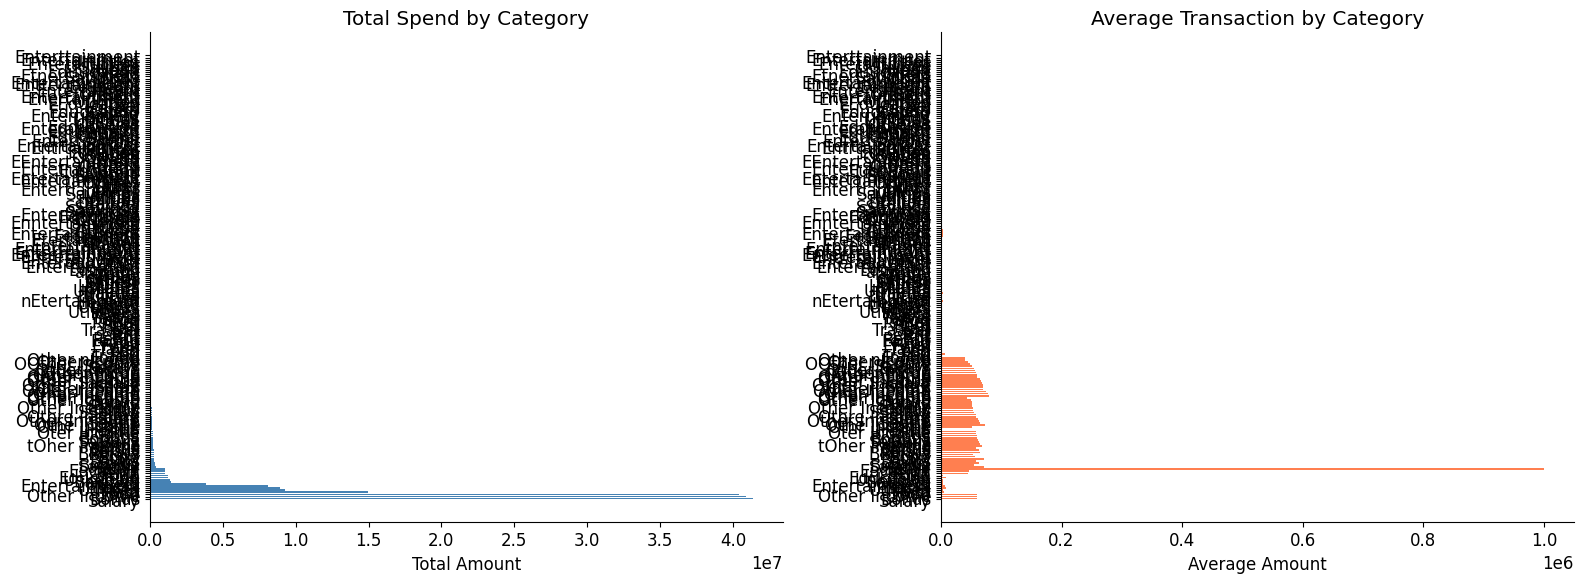

Chart saved to docs/category_spending.png


In [2]:
# Cell 2 - Spending by Category
category_summary = (bw.groupby('category')['amount']
                    .agg(['sum', 'mean', 'count'])
                    .reset_index()
                    .rename(columns={'sum': 'total_spend', 
                                     'mean': 'avg_transaction', 
                                     'count': 'num_transactions'})
                    .sort_values('total_spend', ascending=False))

print("Spending by Category:")
print(category_summary.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total spend by category
axes[0].barh(category_summary['category'], 
             category_summary['total_spend'],
             color='steelblue')
axes[0].set_title('Total Spend by Category')
axes[0].set_xlabel('Total Amount')

# Average transaction by category
axes[1].barh(category_summary['category'], 
             category_summary['avg_transaction'],
             color='coral')
axes[1].set_title('Average Transaction by Category')
axes[1].set_xlabel('Average Amount')

plt.tight_layout()
plt.savefig('../docs/category_spending.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to docs/category_spending.png")

In [3]:
# Cell 3 - Fix category inconsistencies using fuzzy mapping
category_mapping = {
    # Food variations
    'Fodo': 'Food', 'Foood': 'Food', 'Fod': 'Food',
    # Rent variations  
    'Rentt': 'Rent', 'Ren': 'Rent', 'Rент': 'Rent',
    # Education variations
    'Eucation': 'Education', 'Educaton': 'Education', 
    'Eduction': 'Education',
    # Salary variations
    'Salaryy': 'Salary', 'Salry': 'Salary', 'Saary': 'Salary',
    'alary': 'Salary', 'Salray': 'Salary', 'Saalry': 'Salary',
    # Bonus variations
    'Bonnus': 'Bonus', 'Bouns': 'Bonus', 'BBonus': 'Bonus',
    'Bonu': 'Bonus', 'Bonuss': 'Bonus',
    # Entertainment variations
    'Enterainment': 'Entertainment', 'Entertinment': 'Entertainment',
    'Entetainment': 'Entertainment', 'Entertainmnet': 'Entertainment',
    'Enterttainment': 'Entertainment', 'Entertaiment': 'Entertainment',
    # Utilities variations
    'Uttilities': 'Utilities', 'Utlities': 'Utilities',
    'Utilitiess': 'Utilities',
    # Savings variations
    'Savigns': 'Savings', 'Savinsg': 'Savings',
    # Travel variations
    'Travell': 'Travel', 'Traval': 'Travel',
    # Others variations
    'Otherss': 'Others', 'Oters': 'Others'
}

# Apply mapping
bw['category'] = bw['category'].replace(category_mapping)

# Check results
print(f"Categories before: many misspellings")
print(f"Categories after cleaning:")
print(bw['category'].value_counts())
print(f"\nTotal unique categories: {bw['category'].nunique()}")

Categories before: many misspellings
Categories after cleaning:
category
Food             3563
Rent             2879
Travel           1350
Utilities        1193
Entertainment     979
                 ... 
Oher Income         1
Entertainmet        1
Healh               1
Other Incoe         1
Educatioon          1
Name: count, Length: 184, dtype: int64

Total unique categories: 184


In [4]:
pip install thefuzz

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------  1.6/1.6 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 9.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [rapidfuzz]
   ---------------------------------------- 0/2 [rapidfuzz]
   ---------------------------------------- 0/2 [rapidfuzz]
   ---------------------------------------- 0/2 [rapidfuzz]
   -------------------- ------------------- 1/2 [thefuzz]
   ---------------------------------------- 2/2 [thefuzz]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Cell 4 - Smart category cleaning using fuzzy matching
from thefuzz import process

# These are the only valid categories
valid_categories = [
    'Food', 'Rent', 'Travel', 'Utilities', 'Entertainment',
    'Salary', 'Bonus', 'Savings', 'Education', 'Others',
    'Other Income', 'Unknown', 'Healthcare'
]

def clean_category(cat):
    if pd.isnull(cat):
        return 'Unknown'
    # Find closest valid category with similarity score
    match, score = process.extractOne(cat, valid_categories)
    # If similarity is above 70%, use the match
    if score >= 70:
        return match
    else:
        return 'Others'

print("Cleaning categories with fuzzy matching...")
bw['category'] = bw['category'].apply(clean_category)

print(f"Total unique categories after cleaning: {bw['category'].nunique()}")
print()
print("Category distribution:")
print(bw['category'].value_counts())

Cleaning categories with fuzzy matching...
Total unique categories after cleaning: 13

Category distribution:
category
Food             3667
Rent             2998
Travel           1453
Utilities        1273
Entertainment    1084
Salary            730
Bonus             729
Other Income      715
Others            599
Savings           578
Education         334
Healthcare        227
Unknown           153
Name: count, dtype: int64


Spending by Category:
     category  total_spend  avg_transaction  num_transactions
       Salary   44030255.0     60315.417808               730
        Bonus   43564712.0     59759.550069               729
 Other Income   42404445.0     59306.916084               715
         Food   16099469.0      4390.365149              3667
         Rent   10389314.0      3465.414943              2998
    Utilities    9000581.0      7070.369992              1273
       Travel    8206085.0      5647.684102              1453
Entertainment    3903290.0      3600.821033              1084
    Education    2262290.0      6773.323353               334
       Others    1483892.0      2477.282137               599
      Savings    1421878.0      2459.996540               578
      Unknown    1253847.0      8195.078431               153
   Healthcare     163698.0       721.136564               227


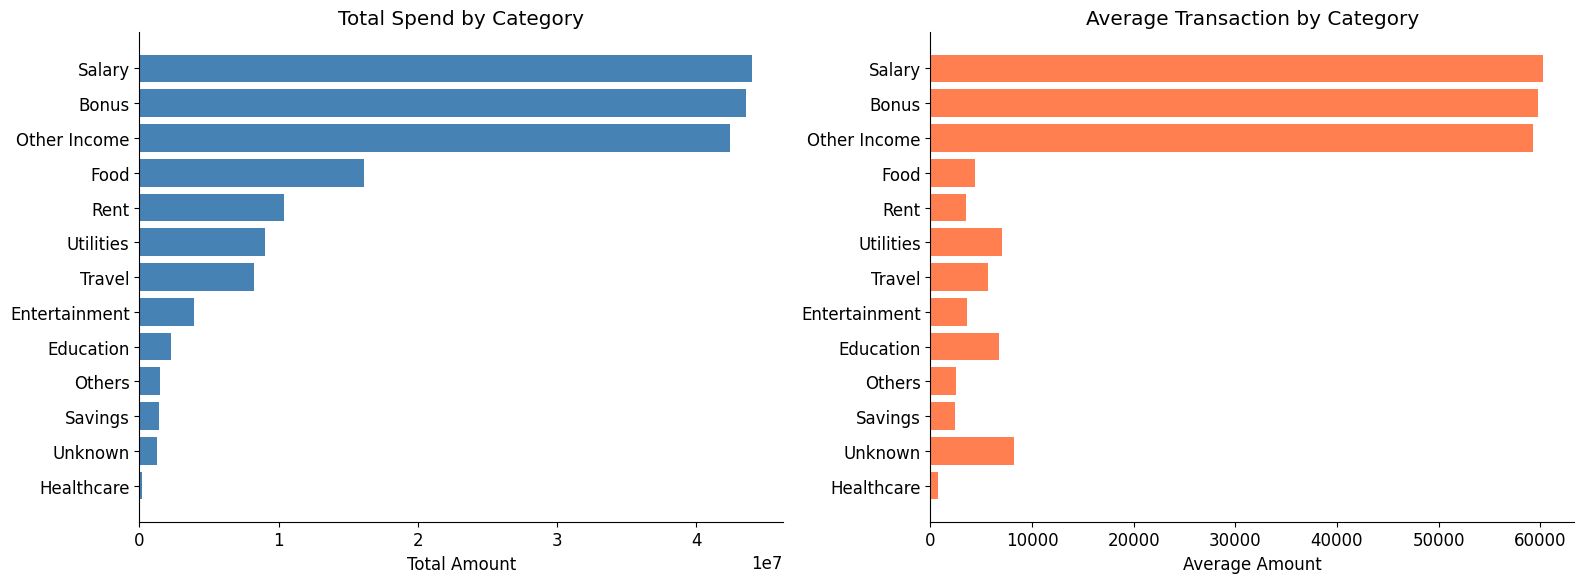

Chart saved to docs/category_spending.png


In [6]:
# Cell 5 - Spending by Category (clean data)
category_summary = (bw.groupby('category')['amount']
                    .agg(['sum', 'mean', 'count'])
                    .reset_index()
                    .rename(columns={'sum': 'total_spend',
                                     'mean': 'avg_transaction',
                                     'count': 'num_transactions'})
                    .sort_values('total_spend', ascending=False))

print("Spending by Category:")
print(category_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(category_summary['category'],
             category_summary['total_spend'],
             color='steelblue')
axes[0].set_title('Total Spend by Category')
axes[0].set_xlabel('Total Amount')
axes[0].invert_yaxis()

axes[1].barh(category_summary['category'],
             category_summary['avg_transaction'],
             color='coral')
axes[1].set_title('Average Transaction by Category')
axes[1].set_xlabel('Average Amount')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../docs/category_spending.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to docs/category_spending.png")

#### Insight 1
Food is the highest-frequency expense category (3,667 transactions) 
but not the highest average transaction. Utilities has the highest 
average transaction value (7,070) despite lower frequency (1,273).
This means food spending is predictable through volume patterns while 
utility spending needs spike detection. Two different forecasting 
strategies are needed for these categories.

In [7]:
# Cell 6 - Separate income vs expenses
expenses = bw[bw['transaction_type'] == 'Expense'].copy()
income = bw[bw['transaction_type'] == 'Income'].copy()

print(f"Total transactions: {bw.shape[0]:,}")
print(f"Expense transactions: {expenses.shape[0]:,}")
print(f"Income transactions: {income.shape[0]:,}")
print()
print(f"Total money spent: {expenses['amount'].sum():,.0f}")
print(f"Total money earned: {income['amount'].sum():,.0f}")
print()
print(f"Average expense transaction: {expenses['amount'].mean():,.0f}")
print(f"Average income transaction: {income['amount'].mean():,.0f}")

# Monthly savings rate
total_income = income['amount'].sum()
total_expense = expenses['amount'].sum()
savings_rate = ((total_income - total_expense) / total_income) * 100
print(f"\nOverall savings rate: {savings_rate:.1f}%")

Total transactions: 14,540
Expense transactions: 12,346
Income transactions: 2,194

Total money spent: 53,045,415
Total money earned: 131,138,341

Average expense transaction: 4,297
Average income transaction: 59,771

Overall savings rate: 59.6%


#### Insight 2
85% of transactions are expenses with an average of 4,297 per transaction.
Income transactions average 59,771 - approximately 14x higher, confirming 
monthly salary credit patterns. The overall savings rate of 59.6% suggests 
this dataset represents financially disciplined users - the LLM advice layer 
should focus on investment optimization rather than basic budgeting.

Monthly spending trend:
year_month    amount year_month_str
   2019-01  210322.0        2019-01
   2019-02 3224591.0        2019-02
   2019-03  235292.0        2019-03
   2019-04 3197126.0        2019-04
   2019-05  228644.0        2019-05
   2019-06 1220901.0        2019-06
   2019-07 1198331.0        2019-07
   2019-08  200848.0        2019-08
   2019-09 1239343.0        2019-09
   2019-10 1185940.0        2019-10
   2019-11 2166542.0        2019-11
   2019-12 2201730.0        2019-12
   2020-01  257609.0        2020-01
   2020-02 1207158.0        2020-02
   2020-03 2187738.0        2020-03
   2020-04  220027.0        2020-04
   2020-05 1206311.0        2020-05
   2020-06  220144.0        2020-06
   2020-07 3226500.0        2020-07
   2020-08 1213516.0        2020-08
   2020-09  214116.0        2020-09
   2020-10  195207.0        2020-10
   2020-11 1233977.0        2020-11
   2020-12 2207957.0        2020-12
   2021-01  206823.0        2021-01
   2021-02  203365.0        2021-02
   2

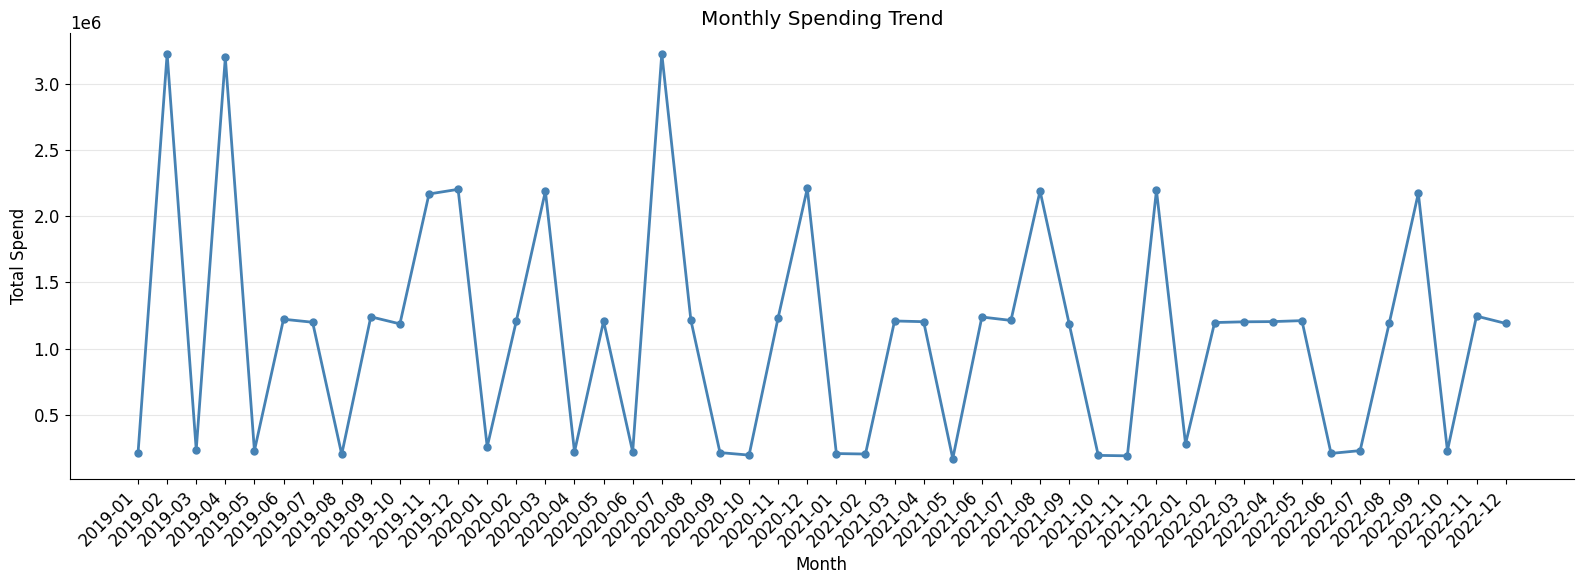

Chart saved to docs/monthly_trend.png


In [8]:
# Cell 7 - Monthly spending trend
expenses['year_month'] = expenses['date'].dt.to_period('M')

monthly_spend = (expenses.groupby('year_month')['amount']
                 .sum()
                 .reset_index())
monthly_spend['year_month_str'] = monthly_spend['year_month'].astype(str)

print("Monthly spending trend:")
print(monthly_spend.to_string(index=False))

plt.figure(figsize=(16, 6))
plt.plot(monthly_spend['year_month_str'], 
         monthly_spend['amount'], 
         marker='o', 
         linewidth=2,
         color='steelblue',
         markersize=5)
plt.title('Monthly Spending Trend')
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to docs/monthly_trend.png")

#### Insight 3
Monthly spending shows a consistent baseline of 1.2M-2.2M with periodic 
spikes reaching 3.2M. Near-zero months indicate data sampling gaps rather 
than actual zero spending. The forecasting model will need to handle these 
gaps — Prophet's missing data handling makes it the right choice over 
simpler moving average models.

Spending by day of week:
day_of_week  total_spend   avg_spend  num_transactions
     Monday    5452626.0 3009.175497              1812
    Tuesday   10497222.0 5870.929530              1788
  Wednesday    8408069.0 4718.332772              1782
   Thursday    8371038.0 4783.450286              1750
     Friday    2458385.0 1465.068534              1678
   Saturday    7458609.0 4107.163546              1816
     Sunday   10399466.0 6046.201163              1720


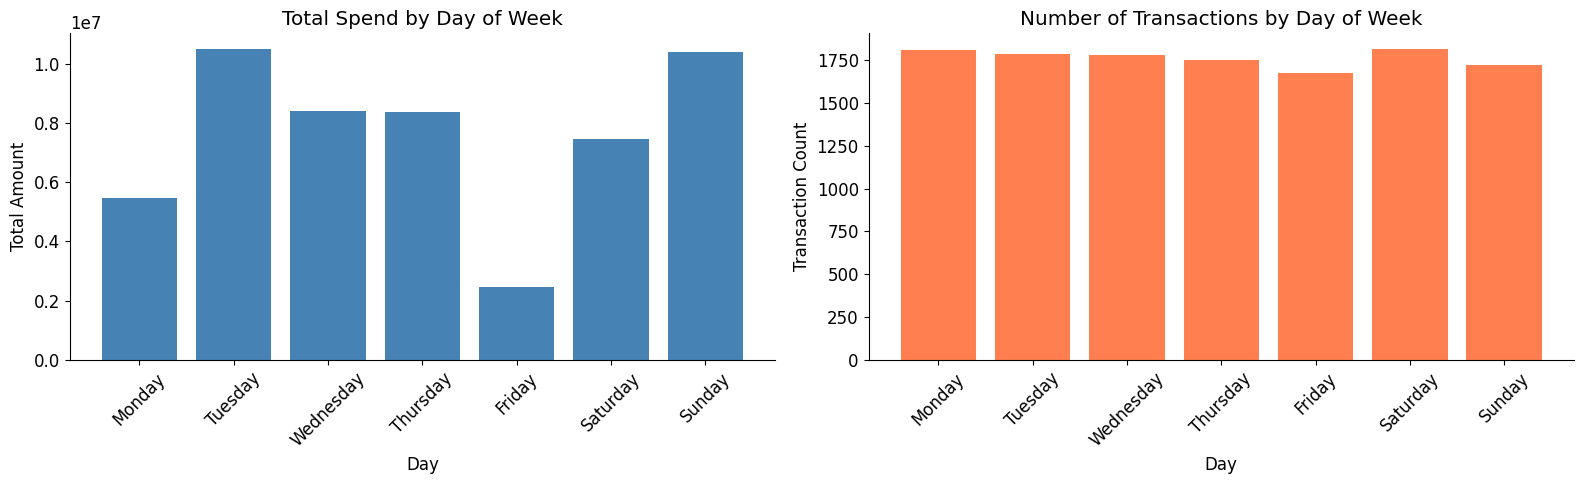

In [9]:
# Cell 8 - Spending by day of week
expenses['day_of_week'] = expenses['date'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

day_spend = (expenses.groupby('day_of_week')['amount']
             .agg(['sum', 'mean', 'count'])
             .reindex(day_order)
             .reset_index()
             .rename(columns={'sum': 'total_spend',
                              'mean': 'avg_spend',
                              'count': 'num_transactions'}))

print("Spending by day of week:")
print(day_spend.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(day_spend['day_of_week'], 
            day_spend['total_spend'],
            color='steelblue')
axes[0].set_title('Total Spend by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Amount')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(day_spend['day_of_week'], 
            day_spend['num_transactions'],
            color='coral')
axes[1].set_title('Number of Transactions by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Transaction Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

#### Insight 4
Transaction frequency is uniform across all days (~1,700-1,800 per day)
but spending amounts vary significantly. Tuesday and Sunday show 2x higher 
total spend than Friday despite similar transaction counts. Friday average 
transaction (1,465) is less than half of Tuesday (5,871). This day-of-week 
pattern becomes a feature called 'is_high_spend_day' in the ML model.

Fraud Overview:
Total transactions: 1,296,675
Fraudulent transactions: 7,506
Fraud rate: 0.58%

Fraud rate by category:
      category  total  fraudulent  fraud_rate
  shopping_net  97543        1713    1.756149
      misc_net  63287         915    1.445795
   grocery_pos 123638        1743    1.409761
  shopping_pos 116672         843    0.722538
 gas_transport 131659         618    0.469394
      misc_pos  79655         250    0.313853
   grocery_net  45452         134    0.294817
        travel  40507         116    0.286370
 entertainment  94014         233    0.247835
 personal_care  90758         220    0.242403
     kids_pets 113035         239    0.211439
   food_dining  91461         151    0.165098
          home 123115         198    0.160825
health_fitness  85879         133    0.154869


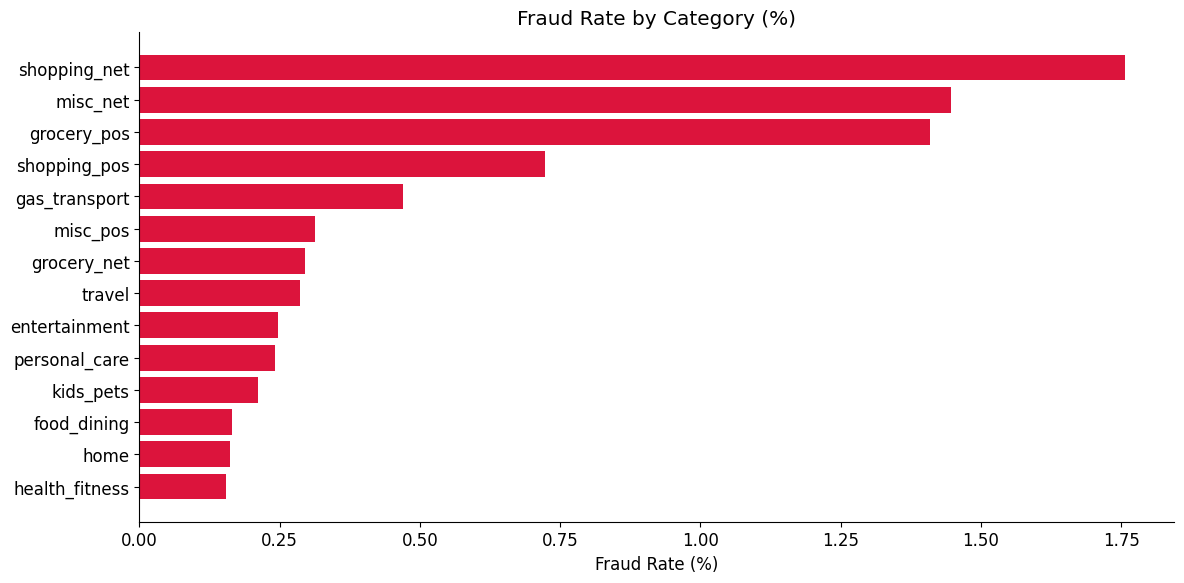

In [10]:
# Cell 9 - Fraud pattern analysis
print("Fraud Overview:")
print(f"Total transactions: {fraud.shape[0]:,}")
print(f"Fraudulent transactions: {fraud['is_fraud'].sum():,}")
print(f"Fraud rate: {fraud['is_fraud'].mean()*100:.2f}%")
print()

# Fraud by category
fraud_by_cat = (fraud.groupby('category')
                .agg(total=('is_fraud', 'count'),
                     fraudulent=('is_fraud', 'sum'))
                .assign(fraud_rate=lambda x: x['fraudulent']/x['total']*100)
                .sort_values('fraud_rate', ascending=False)
                .reset_index())

print("Fraud rate by category:")
print(fraud_by_cat.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(fraud_by_cat['category'], 
         fraud_by_cat['fraud_rate'],
         color='crimson')
plt.title('Fraud Rate by Category (%)')
plt.xlabel('Fraud Rate (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/fraud_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

#### Insight 5
Online transactions (_net suffix) show dramatically higher fraud rates 
than in-person transactions (_pos suffix). shopping_net has the highest 
fraud rate at 1.75% - nearly 3x higher than health_fitness at 0.15%.
This category pattern becomes a critical feature in the Isolation Forest 
anomaly detection model. The LLM alert system will flag online shopping 
and miscellaneous net transactions with higher suspicion scores.